In [11]:
# Instalaciones necesarias
%pip install prophet kagglehub statsmodels scikit-learn

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

# Configuración visual
plt.style.use('fivethirtyeight')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: c:\Users\tteru\.pyenv\pyenv-win\versions\3.12.8\python.exe -m pip install --upgrade pip


In [12]:
# 1. Descargar el dataset usando kagglehub
path = kagglehub.dataset_download("chirag19/air-passengers")

# 2. Identificar el archivo y cargarlo
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# 3. Preparación estricta para series temporales
# Forzamos los nombres de columnas para que no haya errores de "KeyError" o "ValueError"
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df.index.freq = 'MS' # Frecuencia mensual (Month Start)

print("Dataset cargado correctamente:")
print(df.head())

Dataset cargado correctamente:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


In [14]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Total de datos: {len(df)}")
print(f"Entrenamiento (80%): {len(train)}")
print(f"Prueba (20%): {len(test)}")

Total de datos: 144
Entrenamiento (80%): 115
Prueba (20%): 29


In [15]:
# Entrenamos el modelo (usamos el orden 5,1,0 similar al ejemplo de sunspots)
model_arima = ARIMA(train, order=(5,1,0)) 
model_arima_fit = model_arima.fit()

# Realizamos el forecast para la longitud del dataset de test
forecast_arima = model_arima_fit.forecast(steps=len(test))

In [16]:
# Prophet necesita columnas llamadas 'ds' y 'y'
df_prophet_train = train.reset_index()
df_prophet_train.columns = ['ds', 'y']

# Entrenar modelo
model_prophet = Prophet(yearly_seasonality=True)
model_prophet.fit(df_prophet_train)

# Crear dataframe futuro y predecir
future = model_prophet.make_future_dataframe(periods=len(test), freq='MS')
forecast_prophet_full = model_prophet.predict(future)

# Extraer solo la predicción del periodo de test
forecast_prophet = forecast_prophet_full['yhat'].iloc[len(train):].values

19:06:25 - cmdstanpy - INFO - Chain [1] start processing
19:06:25 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
# Métricas para ARIMA
rmse_arima = sqrt(mean_squared_error(test, forecast_arima))
mae_arima = mean_absolute_error(test, forecast_arima)

# Métricas para Prophet
rmse_prophet = sqrt(mean_squared_error(test, forecast_prophet))
mae_prophet = mean_absolute_error(test, forecast_prophet)

# Crear tabla comparativa
resultados = pd.DataFrame({
    'Modelo': ['ARIMA', 'Prophet'],
    'RMSE': [rmse_arima, rmse_prophet],
    'MAE': [mae_arima, mae_prophet]
})

print("Resultados de las Métricas:")
print(resultados)

Resultados de las Métricas:
    Modelo       RMSE        MAE
0    ARIMA  80.663945  67.383501
1  Prophet  41.332489  33.896315


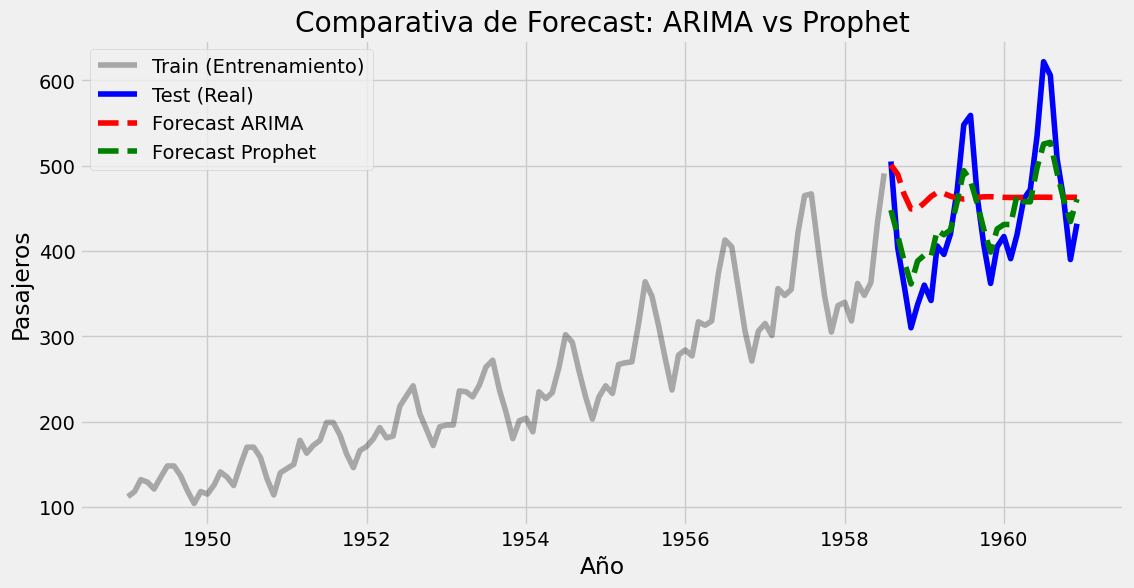

In [18]:
plt.figure(figsize=(12, 6))

# Dibujar datos reales
plt.plot(train.index, train, label='Train (Entrenamiento)', color='black', alpha=0.3)
plt.plot(test.index, test, label='Test (Real)', color='blue')

# Dibujar predicciones
plt.plot(test.index, forecast_arima, label='Forecast ARIMA', color='red', linestyle='--')
plt.plot(test.index, forecast_prophet, label='Forecast Prophet', color='green', linestyle='--')

plt.title('Comparativa de Forecast: ARIMA vs Prophet')
plt.xlabel('Año')
plt.ylabel('Pasajeros')
plt.legend()
plt.show()